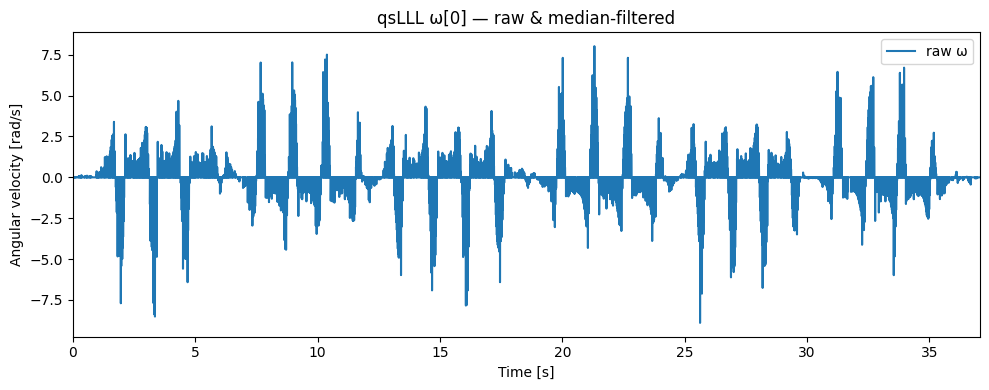

Found 42 peaks and 38 troughs


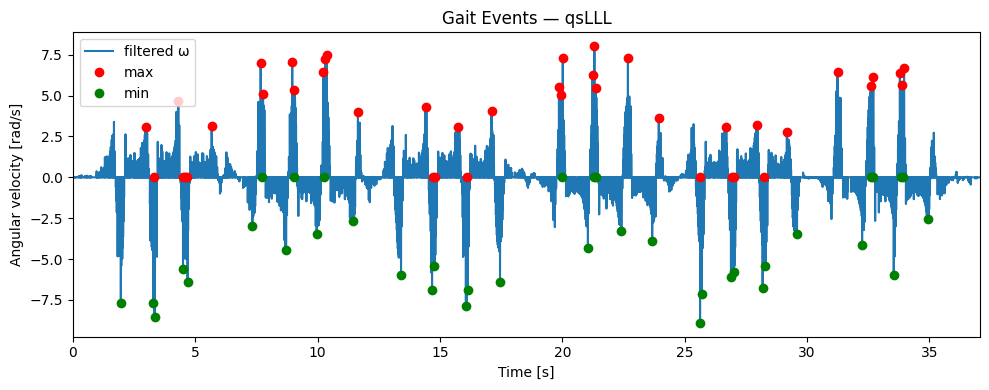

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, medfilt

# --- Configuration ---
file_path = 'S41_A01_T02.raw'
sensor    = 'qsLLL'
fs        = 50                   # IMU sample rate [Hz]
dt        = 1.0 / fs             # constant time step

# --- Load & clean ---
df = pd.read_csv(file_path, header=0)
df.rename(columns={df.columns[0]:'sensor'}, inplace=True)
for c in ['w','x','y','z','timestamp']:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df.dropna(subset=['w','x','y','z','timestamp'], inplace=True)
df = df[df['timestamp'] != 0.0]  # drop calibration rows

# --- Extract the chosen sensor ---
grp = df[df['sensor']==sensor].sort_values('timestamp').reset_index(drop=True)
quats      = grp[['w','x','y','z']].values.copy()
timestamps = grp['timestamp'].values

# --- Build time axis relative to first sample ---
t = (timestamps - timestamps[0])   

# --- Enforce quaternion continuity (avoid sign flips) ---
for i in range(1, len(quats)):
    if np.dot(quats[i-1], quats[i]) < 0:
        quats[i] = -quats[i]

# --- Quaternion helpers ---
def quat_conjugate(q):
    qc = q.copy(); qc[...,1:] *= -1; return qc

def quat_multiply(a, b):
    w1,x1,y1,z1 = a[...,0],a[...,1],a[...,2],a[...,3]
    w2,x2,y2,z2 = b[...,0],b[...,1],b[...,2],b[...,3]
    return np.stack([
        w1*w2 - x1*x2 - y1*y2 - z1*z2,
        w1*x2 + x1*w2 + y1*z2 - z1*y2,
        w1*y2 - x1*z2 + y1*w2 + z1*x2,
        w1*z2 + x1*y2 - y1*x2 + z1*w2
    ], axis=-1)

# --- Compute angular velocity with constant dt ---
q0 = quats[:-1]; q1 = quats[1:]
dq = quat_multiply(q1, quat_conjugate(q0))
w_clean = np.clip(dq[:,0], -1.0, 1.0)
angle   = 2 * np.arccos(w_clean)
sin_h   = np.sqrt(1 - w_clean*w_clean)
axis    = np.zeros((len(dq),3))
mask    = sin_h > 1e-8
axis[mask] = dq[mask,1:] / sin_h[mask,None]
omega3d = axis * (angle/dt)[:,None]
t_omega = t[1:]  # align with ω samples

# --- Select signed component and smooth ---
axis_idx    = np.argmax(np.std(omega3d, axis=0))
omega_comp  = omega3d[:, axis_idx]
# median filter to suppress spikes
#omega_filt  = medfilt(omega_comp, kernel_size=5)

# --- Plot raw vs filtered ω ---
plt.figure(figsize=(10,4))
plt.plot(t_omega, omega_comp, label='raw ω')
#plt.plot(t_omega, omega_filt,  'b',    label='filtered ω')
plt.xlim(0, t_omega[-1])
plt.xlabel('Time [s]')
plt.ylabel('Angular velocity [rad/s]')
plt.title(f'{sensor} ω[{axis_idx}] — raw & median‐filtered')
plt.legend()
plt.tight_layout()
plt.show()

# --- Detect gait events on filtered signal ---
min_dist = int(0.5 * fs)
peaks,   _ = find_peaks(   omega_comp, distance=min_dist, prominence=5)
troughs, _ = find_peaks(- omega_comp, distance=min_dist, prominence=5)
print(f'Found {len(peaks)} peaks and {len(troughs)} troughs')

# --- Plot filtered ω with detected events ---
plt.figure(figsize=(10,4))
plt.plot(t_omega, omega_comp, label='filtered ω')
plt.plot(t_omega[peaks],   omega_comp[peaks],   'ro', label='max')
plt.plot(t_omega[troughs], omega_comp[troughs], 'go', label='min')
plt.xlim(0, t_omega[-1])
plt.xlabel('Time [s]')
plt.ylabel('Angular velocity [rad/s]')
plt.title(f'Gait Events — {sensor}')
plt.legend()
plt.tight_layout()
plt.show()
